Get User Data

In [135]:
import os
from dotenv import load_dotenv
from mal_client import MALClient
from anime_data import AnimeDataClient

load_dotenv()

client_id = os.getenv("CLIENT_ID")

In [136]:
# users = set({'Cresherhsm', 'Mevoll', 'Cheuns', 'Haileytokar', 'dragonenjoyer', 'chenamaty', 'monkeydirene', 'MarnikBe', 'ssafin', 'zClaw_Epic', 'ayumix3', 'ikodrmz', 'heemini', 'I_grV', 'Opelo_Stradyon', 'DanDeku', 'Toaster_toaster', 'SaniLani', 'ArceusComplex', 'MubE', 'SuricateVoador', 'Captn_Cook', 'LILITH_OG', 'DoomSlayer_OG', 'Sturmx', 'AkiAki_Akira', 'kaninhoppning', 'kuzyadam', 'N0rth_5tar', 'KyleAxity_'})

Users data

In [137]:
# users_data = {}
# users_scores = {}

# users = set({'Cresherhsm', 'Mevoll', 'Cheuns', 'Haileytokar', 'dragonenjoyer', 'chenamaty', 'monkeydirene', 'MarnikBe', 'ssafin', 'zClaw_Epic', 'ayumix3', 'ikodrmz', 'heemini', 'I_grV', 'Opelo_Stradyon', 'DanDeku', 'Toaster_toaster', 'SaniLani', 'ArceusComplex', 'MubE', 'SuricateVoador', 'Captn_Cook', 'LILITH_OG', 'DoomSlayer_OG', 'Sturmx', 'AkiAki_Akira', 'kaninhoppning', 'kuzyadam', 'N0rth_5tar', 'KyleAxity_'})
# for user in users:
#     user_data_client = MALClient(client_id, user)
#     user_data = user_data_client.get_user_data()
#     users_data[user] = user_data
#     scores = user_data_client.get_scores(user_data)
#     users_scores[user] = scores

Get anime data from the user animelist

In [138]:
# from anime_data import AnimeDataClient

# anime_data_client = AnimeDataClient(client_id)

# users_anime_data = {}

# for user, user_scores in users_scores.items():
#     print(f"Processing {user}: {len(user_scores)} scored anime")
#     anime_data = anime_data_client.get_anime_data(user_scores.keys())
#     users_anime_data[user] = anime_data
#     print(f"Cached/loaded {len(anime_data)} anime for {user}")

In [139]:
anime_data_client = AnimeDataClient(client_id)

In [140]:
# anime_data_client.print_cache_summary()

Cache 3000 animes

In [141]:
# tv = anime_data_client.cache_ranked_animes("tv", total=1000)
# airing = anime_data_client.cache_ranked_animes("airing", total=1000)
# bypopularity = anime_data_client.cache_ranked_animes("bypopularity", total=1000)
# favorite = anime_data_client.cache_ranked_animes("favorite", total=1000)

Numerical dataset

In [153]:
anime_data = anime_data_client.get_cache()

In [154]:
from anime_features import AnimeFeatureBuilder

builder = AnimeFeatureBuilder(
    anime_data,
    max_tfidf_features=3000,
    n_svd_components=300
)

anime_df = builder.build_features()
builder.svd_explained_variance

np.float64(0.4104185921487374)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# anime_df = pd.DataFrame(anime_data.values())
# anime_df.drop(columns=["main_picture"], inplace=True)
# anime_df.insert(0, 'user_score', scores.values())

# statistics_df = pd.json_normalize(anime_df["statistics"])
# statistics_df = statistics_df.rename(columns={
#     "num_list_users": "statistics_num_list_users",
#     "status.watching": "watching",
#     "status.completed": "completed",
#     "status.on_hold": "on_hold",
#     "status.dropped": "dropped",
#     "status.plan_to_watch": "plan_to_watch",
# })
# statistics_df = statistics_df.apply(pd.to_numeric, errors="coerce")

# anime_df = pd.concat([anime_df.drop(columns=["statistics"]), statistics_df], axis=1)
# anime_df.head()

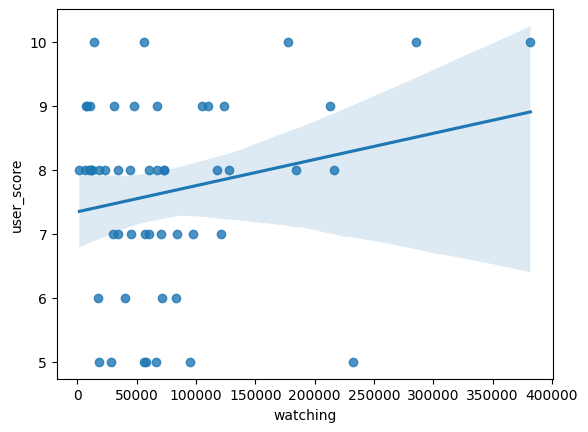

In [ ]:
# sns.regplot(data=anime_df, x="watching", y="user_score")
# plt.show()

In [ ]:
# def scale_0_10(x):
#     anime_df[f"{x}_0_10"] = 10 * (
#     (anime_df[x] - anime_df[x].min()) /
#     (anime_df[x].max() - anime_df[x].min())
# )

In [ ]:
# import statsmodels.api as sm

# scale_0_10("num_episodes")
# scale_0_10("popularity")
# scale_0_10("watching")

# anime_df["mean_c"] = anime_df["mean"] - anime_df["mean"].mean()
# anime_df["episodes_c"] = anime_df["num_episodes_0_10"] - anime_df["num_episodes_0_10"].mean()
# anime_df["popularity_c"] = anime_df["popularity_0_10"] - anime_df["popularity_0_10"].mean()
# anime_df["watching_c"] = anime_df["watching_0_10"] - anime_df["watching_0_10"].mean()

# anime_df["mean_c2"] = anime_df["mean_c"] ** 2
# anime_df["episodes_c2"] = anime_df["episodes_c"] ** 2
# anime_df["popularity_c2"] = anime_df["popularity_c"] ** 2
# anime_df["watching_c2"] = anime_df["watching_c"] ** 2

# #Restricted model
# X = anime_df[["mean", "num_episodes_0_10", "popularity_0_10", "watching_0_10", "mean"]]
# y = anime_df["user_score"]

# X = sm.add_constant(X)
# restricted_model = sm.OLS(y, X).fit()

# # Full model: linear + nonlinear term
# X_full = anime_df[["mean", "num_episodes_0_10", "popularity_0_10", "watching_0_10", "popularity_c2"]]
# X_full = sm.add_constant(X_full)
# full_model = sm.OLS(y, X_full).fit()

# print(full_model.compare_f_test(restricted_model))
# print(full_model.summary())

(np.float64(4.294502596142695), np.float64(0.04374631024374631), np.float64(1.0))
                            OLS Regression Results                            
Dep. Variable:             user_score   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     12.01
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           1.63e-07
Time:                        23:17:43   Log-Likelihood:                -73.197
No. Observations:                  53   AIC:                             158.4
Df Residuals:                      47   BIC:                             170.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------